# Generación de 100 muestras aleatorias sobre una recta y = mx + b

**Curso:** SI3003 — Inteligencia Artificial

**Objetivo:** generar 100 pares de coordenadas `(x, y)` que provienen de una recta *y = mx + b* a la que se le añade ruido aleatorio (dispersión), y visualizar los puntos generados.

## Metodología

1. Fijar los parámetros de la recta: pendiente *m* e intercepto *b*.
2. Muestrear cada `x` de forma uniforme en el intervalo `[0, 10]`.
3. Calcular el valor ideal sobre la recta: `y_ideal = m * x + b`.
4. Añadir ruido gaussiano: `y = y_ideal + ε`, con `ε ~ N(0, σ²)`.
5. Graficar los puntos `(x, y)` junto con la recta teórica.


## 1. Importación de librerías

- `numpy`: generación de números aleatorios.
- `matplotlib`: graficación de los puntos.


In [47]:
import numpy as np
import matplotlib.pyplot as plt

# Semilla para reproducibilidad
np.random.seed(42)

## 2. Parámetros de la recta

Se definen la pendiente `m` y el intercepto `b` de la recta generadora de los datos: `y = m * x + b`.


In [48]:
# Parámetros de la recta: y = m * x + b
m = 2.0   # pendiente
b = 1.0   # intercepto

print(f"Recta generadora: y = {m}x + {b}")

Recta generadora: y = 2.0x + 1.0


## 3. Generación de las 100 muestras con ruido

Las coordenadas `x` se muestrean de forma uniforme en `[0, 10]`. A cada valor de `y` (calculado sobre la recta) se le suma un **ruido gaussiano** con media `0` y desviación estándar `sigma`, que controla la dispersión de los puntos respecto a la recta.


In [49]:
# Número de muestras
n_muestras = 100

# Coordenadas x muestreadas uniformemente en [0, 10]
x = np.random.uniform(0.0, 10.0, n_muestras)

# Ruido gaussiano (media 0, desviación estándar sigma)
sigma = 2.0
ruido = np.random.normal(loc=0.0, scale=sigma, size=n_muestras)

# Coordenadas y: valor sobre la recta + ruido
y = m * x + b + ruido

print(f"Total de muestras: {x.size}")
print(f"Rango de x: [{x.min():.2f}, {x.max():.2f}]")
print(f"Rango de y: [{y.min():.2f}, {y.max():.2f}]")

Total de muestras: 100
Rango de x: [0.06, 9.87]
Rango de y: [0.07, 22.30]


## 4. Visualización de los puntos generados

Cada muestra `(x, y)` se dibuja como un punto (diagrama de dispersión) y, como referencia, se superpone la recta teórica `y = m * x + b` sin ruido.


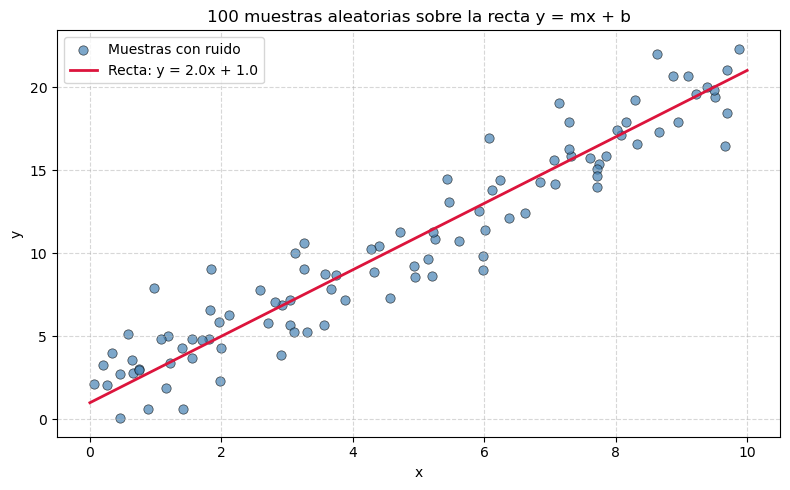

In [50]:
fig, ax = plt.subplots(figsize=(8, 5))

# Puntos generados (con ruido)
ax.scatter(x, y, s=45, color="steelblue", alpha=0.7, edgecolors="black", linewidths=0.5, label="Muestras con ruido")

# Recta teórica sin ruido
x_recta = np.linspace(0.0, 10.0, 100)
ax.plot(x_recta, m * x_recta + b, color="crimson", linewidth=2, label=f"Recta: y = {m}x + {b}")

ax.set_title("100 muestras aleatorias sobre la recta y = mx + b")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## 5. (Extra) Comparación con distintos niveles de ruido

Cuanto mayor es `sigma`, mayor es la dispersión de los puntos respecto a la recta. A continuación se genera la misma recta con tres niveles de ruido distintos para comparar.


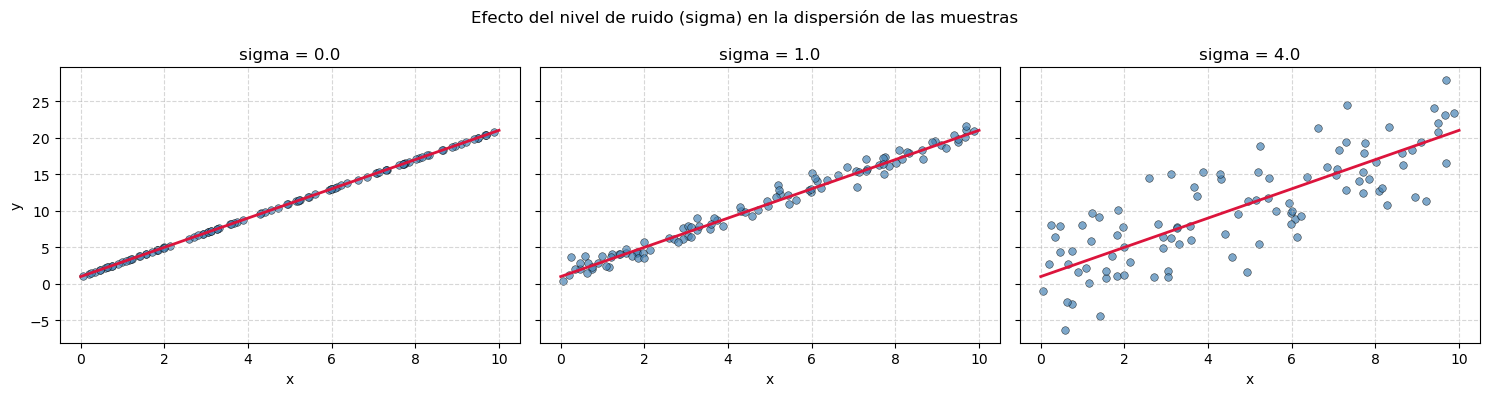

In [51]:
niveles_ruido = [0.0, 1.0, 4.0]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)

for ax_i, s in zip(axes, niveles_ruido):
    ruido_i = np.random.normal(0.0, s, n_muestras)
    y_i = m * x + b + ruido_i
    ax_i.scatter(x, y_i, s=30, color="steelblue", alpha=0.7, edgecolors="black", linewidths=0.4)
    ax_i.plot(x_recta, m * x_recta + b, color="crimson", linewidth=2)
    ax_i.set_title(f"sigma = {s}")
    ax_i.set_xlabel("x")
    ax_i.grid(True, linestyle="--", alpha=0.5)

axes[0].set_ylabel("y")
fig.suptitle("Efecto del nivel de ruido (sigma) en la dispersión de las muestras")
plt.tight_layout()
plt.show()

## 6. Función de costo: MSE

Error cuadrático medio entre `y_real` y `y_estimado`.


In [52]:
def mse(y_real, y_estimado):
    return np.mean((y_real - y_estimado) ** 2)

## 7. Neurona artificial de 5 entradas

Una neurona: `y = f(sum(w_i * x_i))`, con activación **on/off** (escalón). Las 5 entradas son `x`, `x²`, `x³`, `sin(x)` y el **offset** (bias = 1). Buscamos los mejores `w_i` de forma iterativa, minimizando el MSE.

**Nota:** se espera un mal resultado — la activación on/off solo entrega 0 o 1, no puede representar una recta. Esto motiva a actualizar la neurona en los siguientes ejercicios.


In [53]:
# Matriz de entradas de la neurona: 5 entradas por muestra
X = np.column_stack([
    x,               # x1: x
    x ** 2,          # x2: x^2
    x ** 3,          # x3: x^3
    np.sin(x),       # x4: sin(x)
    np.ones(n_muestras)  # x5: offset (bias)
])

def activacion_on_off(s):
    """Función de activación on/off (escalón)."""
    return np.where(s >= 0.0, 1.0, 0.0)

def neurona(X, w):
    """y = f(sum(w_i * x_i))."""
    return activacion_on_off(X @ w)

In [54]:
# Búsqueda iterativa de los mejores w_i (aleatoria)
iteraciones = 5000
mejor_mse = np.inf
mejores_w = None
historial = []

for i in range(iteraciones):
    w = np.random.normal(0.0, 1.0, size=5)
    y_est = neurona(X, w)
    costo = mse(y, y_est)
    historial.append(costo)
    if costo < mejor_mse:
        mejor_mse = costo
        mejores_w = w

print(f"Mejores w_i encontrados: {np.round(mejores_w, 4)}")
print(f"  w1 (x):      {mejores_w[0]:.4f}")
print(f"  w2 (x^2):    {mejores_w[1]:.4f}")
print(f"  w3 (x^3):    {mejores_w[2]:.4f}")
print(f"  w4 (sin x):  {mejores_w[3]:.4f}")
print(f"  w5 (offset): {mejores_w[4]:.4f}")
print(f"MSE mínimo alcanzado: {mejor_mse:.4f}")

Mejores w_i encontrados: [-0.6466 -1.0815  1.6871  0.8816 -0.008 ]
  w1 (x):      -0.6466
  w2 (x^2):    -1.0815
  w3 (x^3):    1.6871
  w4 (sin x):  0.8816
  w5 (offset): -0.0080
MSE mínimo alcanzado: 123.5111


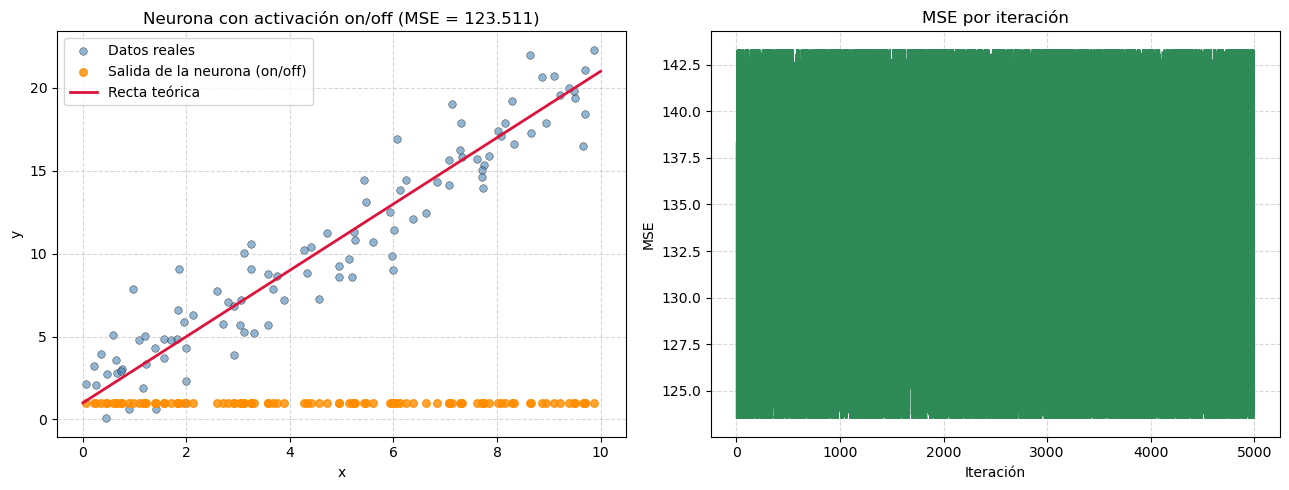

In [55]:
# Visualización: la neurona con activación on/off NO puede ajustar la recta
y_est = neurona(X, mejores_w)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(x, y, s=30, color="steelblue", alpha=0.6, edgecolors="black", linewidths=0.4, label="Datos reales")
axes[0].scatter(x, y_est, s=30, color="darkorange", alpha=0.8, label="Salida de la neurona (on/off)")
axes[0].plot(x_recta, m * x_recta + b, color="crimson", linewidth=2, label="Recta teórica")
axes[0].set_title(f"Neurona con activación on/off (MSE = {mejor_mse:.3f})")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.5)

axes[1].plot(historial, color="seagreen", linewidth=1)
axes[1].set_title("MSE por iteración")
axes[1].set_xlabel("Iteración")
axes[1].set_ylabel("MSE")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## 8. Neurona con activación sigmoide

Mismas 5 entradas (incluido el offset), pero `f` es ahora la **sigmoide**. Se repite la estimación de la recta buscando los mejores `w_i` minimizando el MSE con descenso por gradiente.


In [56]:
# Entradas con escalas comparables (la sigmoide requiere valores controlados)
X_sig = np.column_stack([
    x / 10.0,             # x1: x normalizada
    x ** 2 / 100.0,       # x2: x^2 normalizada
    x ** 3 / 1000.0,      # x3: x^3 normalizada
    np.sin(x),            # x4: sin(x)
    np.ones(n_muestras),  # x5: offset (bias)
])

# y se lleva a [0, 1], el rango de la sigmoide
y_min, y_max = y.min(), y.max()
y_norm = (y - y_min) / (y_max - y_min)

def activacion_sigmoide(s):
    """Función de activación sigmoide."""
    return 1.0 / (1.0 + np.exp(-s))

def neurona_sigmoide(X, w):
    """y = f(sum(w_i * x_i)) con f = sigmoide."""
    return activacion_sigmoide(X @ w)

In [57]:
# Descenso por gradiente para encontrar los mejores w_i
w = np.zeros(5)
tasa_aprendizaje = 1.0
epocas = 20000
historial_sig = []

for _ in range(epocas):
    y_est = neurona_sigmoide(X_sig, w)
    grad = (2.0 / n_muestras) * (X_sig.T @ ((y_est - y_norm) * y_est * (1.0 - y_est)))
    w -= tasa_aprendizaje * grad
    historial_sig.append(mse(y_norm, neurona_sigmoide(X_sig, w)))

y_est_norm = neurona_sigmoide(X_sig, w)
y_est_real = y_est_norm * (y_max - y_min) + y_min

print(f"Mejores w_i encontrados: {np.round(w, 4)}")
print(f"  w1 (x):      {w[0]:.4f}")
print(f"  w2 (x^2):    {w[1]:.4f}")
print(f"  w3 (x^3):    {w[2]:.4f}")
print(f"  w4 (sin x):  {w[3]:.4f}")
print(f"  w5 (offset): {w[4]:.4f}")
print(f"MSE (y normalizada): {mse(y_norm, y_est_norm):.4f}")
print(f"MSE (escala real):   {mse(y, y_est_real):.4f}")

Mejores w_i encontrados: [ 3.0953  0.6577  0.382   0.0075 -1.9008]
  w1 (x):      3.0953
  w2 (x^2):    0.6577
  w3 (x^3):    0.3820
  w4 (sin x):  0.0075
  w5 (offset): -1.9008
MSE (y normalizada): 0.0063
MSE (escala real):   3.1283


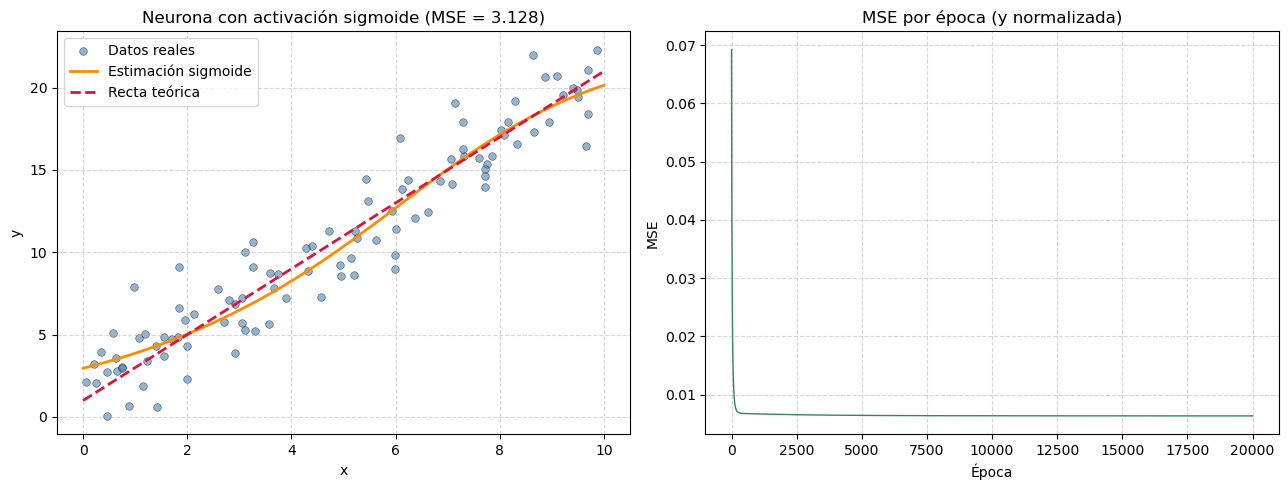

In [58]:
# Estimación de la recta con la neurona sigmoide
X_recta_sig = np.column_stack([
    x_recta / 10.0,
    x_recta ** 2 / 100.0,
    x_recta ** 3 / 1000.0,
    np.sin(x_recta),
    np.ones(x_recta.size),
])
y_sig = neurona_sigmoide(X_recta_sig, w) * (y_max - y_min) + y_min

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(x, y, s=30, color="steelblue", alpha=0.6, edgecolors="black", linewidths=0.4, label="Datos reales")
axes[0].plot(x_recta, y_sig, color="darkorange", linewidth=2, label="Estimación sigmoide")
axes[0].plot(x_recta, m * x_recta + b, color="crimson", linewidth=2, linestyle="--", label="Recta teórica")
axes[0].set_title(f"Neurona con activación sigmoide (MSE = {mse(y, y_est_real):.3f})")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.5)

axes[1].plot(historial_sig, color="seagreen", linewidth=1)
axes[1].set_title("MSE por época (y normalizada)")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("MSE")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## 9. ANN para clasificar el dataset Wine

Red `13 → 10 → 3`: todas las entradas conectadas a las 3 neuronas de salida (una por clase). Activación **sigmoide**, costo **MSE**, estimación iterativa de los `w_i`. Split 70/30, CV de 5 folds, métricas de desempeño y frontera de decisión (visualizada con 2 características).


In [59]:
# Dataset Wine: 13 características y 3 clases
try:
    from sklearn.datasets import load_wine
    wine = load_wine()
    Xw = wine.data.astype(float)
    yw = wine.target
except Exception:
    import io, urllib.request
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data"
    texto = urllib.request.urlopen(url).read().decode("utf-8")
    datos = np.genfromtxt(io.StringIO(texto), delimiter=",")
    Xw = datos[:, 1:]
    yw = datos[:, 0].astype(int) - 1

# Estandarización (13 entradas) y codificación one-hot
Xw = (Xw - Xw.mean(axis=0)) / Xw.std(axis=0)
Yw = np.eye(3)[yw]

# Split 70/30
rng = np.random.default_rng(42)
idx = rng.permutation(len(Xw))
n_train = int(0.7 * len(Xw))
idx_tr, idx_te = idx[:n_train], idx[n_train:]
X_tr, Y_tr, y_tr = Xw[idx_tr], Yw[idx_tr], yw[idx_tr]
X_te, Y_te, y_te = Xw[idx_te], Yw[idx_te], yw[idx_te]

# 2 características (flavanoids, proline) solo para visualizar la frontera
X2 = Xw[:, [6, 12]]
X2_tr, X2_te = X2[idx_tr], X2[idx_te]

print(f"Muestras: {len(Xw)} | Entradas de la red: {Xw.shape[1]} | Clases: 3")
print(f"Entrenamiento: {len(idx_tr)} muestras | Prueba: {len(idx_te)} muestras")

Muestras: 178 | Entradas de la red: 13 | Clases: 3
Entrenamiento: 124 muestras | Prueba: 54 muestras


In [60]:
# Red neuronal 13 -> 10 -> 3 (todas las entradas conectadas), sigmoide, costo MSE
def entrenar_ann(X, Y, n_oculta=10, epocas=3000, tasa=0.5, semilla=0):
    rng = np.random.default_rng(semilla)
    n, d = X.shape
    k = Y.shape[1]
    W1 = rng.normal(0.0, 0.5, (d, n_oculta)); b1 = np.zeros(n_oculta)
    W2 = rng.normal(0.0, 0.5, (n_oculta, k)); b2 = np.zeros(k)
    historial = []
    for _ in range(epocas):
        A1 = activacion_sigmoide(X @ W1 + b1)
        A2 = activacion_sigmoide(A1 @ W2 + b2)
        historial.append(mse(A2, Y))
        # Retropropagación
        dZ2 = (2.0 / n) * (A2 - Y) * A2 * (1.0 - A2)
        dW2, db2 = A1.T @ dZ2, dZ2.sum(axis=0)
        dZ1 = (dZ2 @ W2.T) * A1 * (1.0 - A1)
        dW1, db1 = X.T @ dZ1, dZ1.sum(axis=0)
        W1 -= tasa * dW1; b1 -= tasa * db1
        W2 -= tasa * dW2; b2 -= tasa * db2
    return (W1, b1, W2, b2), historial

def predecir_ann(modelo, X):
    W1, b1, W2, b2 = modelo
    A2 = activacion_sigmoide(activacion_sigmoide(X @ W1 + b1) @ W2 + b2)
    return A2, np.argmax(A2, axis=1)

In [61]:
# Validación cruzada de 5 folds sobre el 70% de entrenamiento
def validacion_cruzada(X, y, k_folds=5):
    rng = np.random.default_rng(42)
    folds = np.array_split(rng.permutation(len(X)), k_folds)
    exactitudes = []
    for i in range(k_folds):
        val = folds[i]
        trn = np.concatenate([folds[j] for j in range(k_folds) if j != i])
        modelo, _ = entrenar_ann(X[trn], np.eye(3)[y[trn]])
        _, pred = predecir_ann(modelo, X[val])
        exactitudes.append(np.mean(pred == y[val]))
    return np.array(exactitudes)

acc_cv = validacion_cruzada(X_tr, y_tr)
print("Exactitud por fold:", np.round(acc_cv, 4))
print(f"Exactitud CV (5-fold): {acc_cv.mean():.4f} ± {acc_cv.std():.4f}")

Exactitud por fold: [1.   0.92 1.   0.96 1.  ]
Exactitud CV (5-fold): 0.9760 ± 0.0320


In [62]:
# Entrenamiento final con el 70% y métricas de desempeño en el 30% de prueba
modelo_wine, historial_wine = entrenar_ann(X_tr, Y_tr, n_oculta=10, epocas=3000, tasa=0.5, semilla=0)

def metricas_clasificacion(y_real, y_pred, n_clases=3):
    """Exactitud, matriz de confusión, precisión, recall y F1."""
    matriz = np.zeros((n_clases, n_clases), dtype=int)
    for r, p in zip(y_real, y_pred):
        matriz[r, p] += 1
    tp = matriz.diagonal().astype(float)
    soporte_real = matriz.sum(axis=1)
    soporte_pred = matriz.sum(axis=0)
    precision = np.divide(tp, soporte_pred, out=np.zeros(n_clases), where=soporte_pred != 0)
    recall = np.divide(tp, soporte_real, out=np.zeros(n_clases), where=soporte_real != 0)
    f1 = np.divide(2.0 * precision * recall, precision + recall, out=np.zeros(n_clases), where=(precision + recall) != 0)
    exactitud = np.mean(y_real == y_pred)
    return exactitud, matriz, precision, recall, f1

_, pred_tr = predecir_ann(modelo_wine, X_tr)
_, pred_te = predecir_ann(modelo_wine, X_te)
exactitud, _, precision, recall, f1 = metricas_clasificacion(y_te, pred_te)

print(f"Exactitud entrenamiento (70%): {np.mean(pred_tr == y_tr):.4f}")
print(f"Exactitud prueba (30%):        {exactitud:.4f}")
for c in range(3):
    print(f"  Clase {c}: precision = {precision[c]:.4f} | recall = {recall[c]:.4f} | F1 = {f1[c]:.4f}")
print(f"  Macro: precision = {precision.mean():.4f} | recall = {recall.mean():.4f} | F1 = {f1.mean():.4f}")
print(f"Error final (MSE en entrenamiento): {historial_wine[-1]:.4f}")

Exactitud entrenamiento (70%): 1.0000
Exactitud prueba (30%):        1.0000
  Clase 0: precision = 1.0000 | recall = 1.0000 | F1 = 1.0000
  Clase 1: precision = 1.0000 | recall = 1.0000 | F1 = 1.0000
  Clase 2: precision = 1.0000 | recall = 1.0000 | F1 = 1.0000
  Macro: precision = 1.0000 | recall = 1.0000 | F1 = 1.0000
Error final (MSE en entrenamiento): 0.0006


### 9.1 Módulo: matriz de confusión


Matriz de confusión — ANN 13->10->3 (prueba 30%)
            Pred 0  Pred 1  Pred 2   Total
    Real 0      24       0       0      24
    Real 1       0      14       0      14
    Real 2       0       0      16      16
Exactitud en prueba: 1.0000


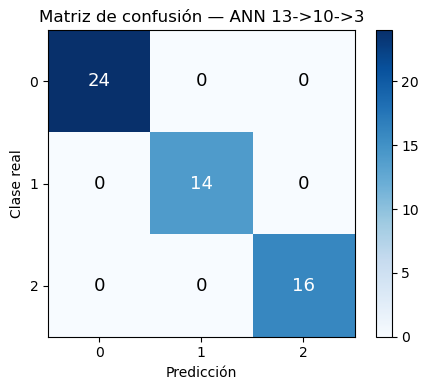

In [63]:
# Módulo independiente: cálculo y visualización de la matriz de confusión
def imprimir_matriz_confusion(matriz, titulo="Matriz de confusión"):
    """Muestra la matriz con totales por clase."""
    print(titulo)
    print(f"{'':>10}{'Pred 0':>8}{'Pred 1':>8}{'Pred 2':>8}{'Total':>8}")
    for i, fila in enumerate(matriz):
        print(f"{f'Real {i}':>10}{fila[0]:>8}{fila[1]:>8}{fila[2]:>8}{fila.sum():>8}")

exactitud_mc, matriz_conf, _, _, _ = metricas_clasificacion(y_te, pred_te)
imprimir_matriz_confusion(matriz_conf, "Matriz de confusión — ANN 13->10->3 (prueba 30%)")
print(f"Exactitud en prueba: {exactitud_mc:.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(matriz_conf, cmap="Blues")
for i in range(3):
    for j in range(3):
        ax.text(j, i, matriz_conf[i, j], ha="center", va="center",
                color="white" if matriz_conf[i, j] > matriz_conf.max() / 2 else "black", fontsize=13)
ax.set_title("Matriz de confusión — ANN 13->10->3")
ax.set_xlabel("Predicción")
ax.set_ylabel("Clase real")
ax.set_xticks(range(3)); ax.set_yticks(range(3))
fig.colorbar(im)
plt.tight_layout()
plt.show()

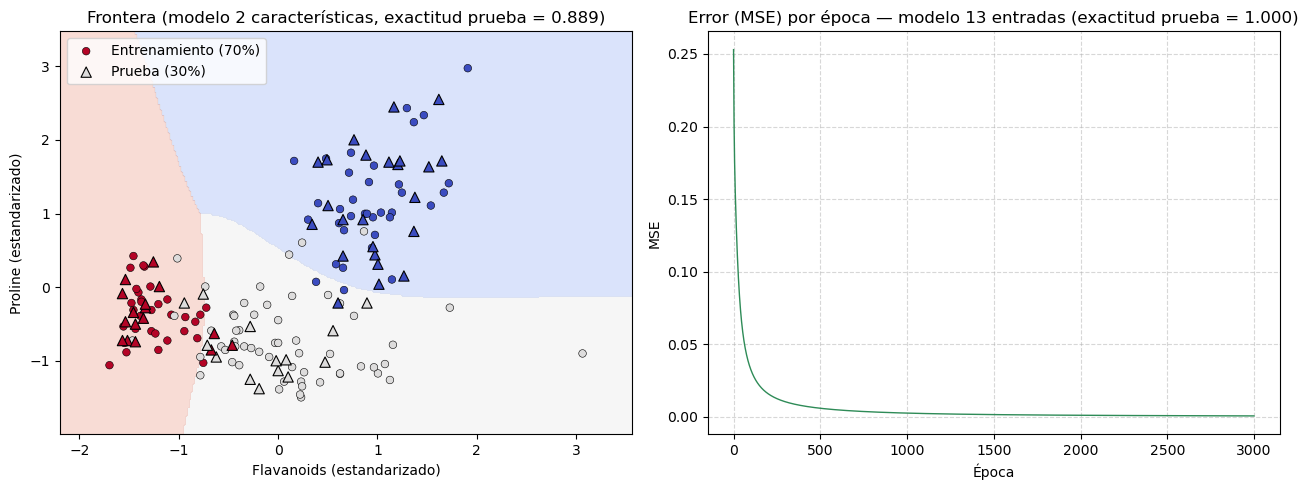

In [64]:
# Frontera de decisión (modelo auxiliar con 2 características) y curva de error
modelo_frontera, _ = entrenar_ann(X2_tr, Y_tr, n_oculta=10, epocas=3000, tasa=0.5, semilla=0)
_, pred_frontera = predecir_ann(modelo_frontera, X2_te)
acc_frontera = np.mean(pred_frontera == y_te)

xx, yy = np.meshgrid(
    np.linspace(X2[:, 0].min() - 0.5, X2[:, 0].max() + 0.5, 300),
    np.linspace(X2[:, 1].min() - 0.5, X2[:, 1].max() + 0.5, 300),
)
_, frontera = predecir_ann(modelo_frontera, np.column_stack([xx.ravel(), yy.ravel()]))
frontera = frontera.reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].contourf(xx, yy, frontera, levels=[-0.5, 0.5, 1.5, 2.5], alpha=0.25, cmap="coolwarm")
axes[0].scatter(X2_tr[:, 0], X2_tr[:, 1], c=y_tr, cmap="coolwarm", s=30, edgecolors="black", linewidths=0.4, label="Entrenamiento (70%)")
axes[0].scatter(X2_te[:, 0], X2_te[:, 1], c=y_te, cmap="coolwarm", marker="^", s=55, edgecolors="black", linewidths=0.8, label="Prueba (30%)")
axes[0].set_title(f"Frontera (modelo 2 características, exactitud prueba = {acc_frontera:.3f})")
axes[0].set_xlabel("Flavanoids (estandarizado)")
axes[0].set_ylabel("Proline (estandarizado)")
axes[0].legend()

axes[1].plot(historial_wine, color="seagreen", linewidth=1)
axes[1].set_title(f"Error (MSE) por época — modelo 13 entradas (exactitud prueba = {exactitud:.3f})")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("MSE")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## 10. Ejercicio siguiente: MLP (Multi Layer Perceptron)

Red con **dos capas ocultas** `13 → 16 → 8 → 3` (sigmoide, costo MSE), entrenada con el mismo split 70/30. Se muestran su matriz de confusión y la comparación con la red de una capa oculta del ejercicio anterior.


In [65]:
# MLP 13 -> 16 -> 8 -> 3 (sigmoide en todas las capas), costo MSE
def entrenar_mlp(X, Y, capas=(16, 8), epocas=4000, tasa=0.5, semilla=0):
    rng = np.random.default_rng(semilla)
    dims = [X.shape[1], *capas, Y.shape[1]]
    W = [rng.normal(0.0, 0.5, (dims[i], dims[i + 1])) for i in range(len(dims) - 1)]
    b = [np.zeros(dims[i + 1]) for i in range(len(dims) - 1)]
    n = X.shape[0]
    historial = []
    for _ in range(epocas):
        activaciones = [X]
        for Wi, bi in zip(W, b):
            activaciones.append(activacion_sigmoide(activaciones[-1] @ Wi + bi))
        A = activaciones[-1]
        historial.append(mse(A, Y))
        # Retropropagación a través de todas las capas
        delta = (2.0 / n) * (A - Y) * A * (1.0 - A)
        for i in range(len(W) - 1, -1, -1):
            dW = activaciones[i].T @ delta
            db = delta.sum(axis=0)
            if i > 0:
                delta = (delta @ W[i].T) * activaciones[i] * (1.0 - activaciones[i])
            W[i] -= tasa * dW
            b[i] -= tasa * db
    return (W, b), historial

def predecir_mlp(modelo, X):
    W, b = modelo
    A = X
    for Wi, bi in zip(W, b):
        A = activacion_sigmoide(A @ Wi + bi)
    return A, np.argmax(A, axis=1)

In [66]:
# Entrenamiento del MLP y resultados en el 30% de prueba
modelo_mlp, historial_mlp = entrenar_mlp(X_tr, Y_tr, capas=(16, 8), epocas=4000, tasa=0.5, semilla=0)
_, pred_mlp_tr = predecir_mlp(modelo_mlp, X_tr)
_, pred_mlp_te = predecir_mlp(modelo_mlp, X_te)
exactitud_mlp, _, precision_mlp, recall_mlp, f1_mlp = metricas_clasificacion(y_te, pred_mlp_te)

print(f"Exactitud entrenamiento (70%): {np.mean(pred_mlp_tr == y_tr):.4f}")
print(f"Exactitud prueba (30%):        {exactitud_mlp:.4f}")
for c in range(3):
    print(f"  Clase {c}: precision = {precision_mlp[c]:.4f} | recall = {recall_mlp[c]:.4f} | F1 = {f1_mlp[c]:.4f}")
print(f"  Macro: precision = {precision_mlp.mean():.4f} | recall = {recall_mlp.mean():.4f} | F1 = {f1_mlp.mean():.4f}")
print(f"Error final (MSE en entrenamiento): {historial_mlp[-1]:.4f}")

Exactitud entrenamiento (70%): 1.0000
Exactitud prueba (30%):        1.0000
  Clase 0: precision = 1.0000 | recall = 1.0000 | F1 = 1.0000
  Clase 1: precision = 1.0000 | recall = 1.0000 | F1 = 1.0000
  Clase 2: precision = 1.0000 | recall = 1.0000 | F1 = 1.0000
  Macro: precision = 1.0000 | recall = 1.0000 | F1 = 1.0000
Error final (MSE en entrenamiento): 0.0003


Matriz de confusión — MLP 13->16->8->3 (prueba 30%)
            Pred 0  Pred 1  Pred 2   Total
    Real 0      24       0       0      24
    Real 1       0      14       0      14
    Real 2       0       0      16      16
Exactitud en prueba: 1.0000


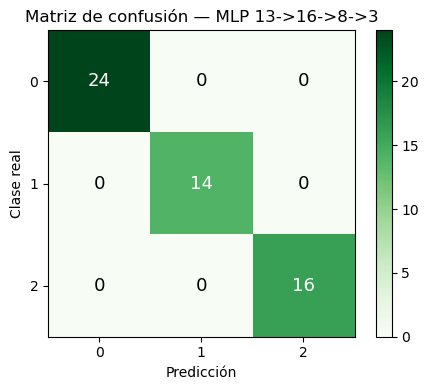

In [67]:
# Módulo: matriz de confusión del MLP
_, matriz_mlp, _, _, _ = metricas_clasificacion(y_te, pred_mlp_te)
imprimir_matriz_confusion(matriz_mlp, "Matriz de confusión — MLP 13->16->8->3 (prueba 30%)")
print(f"Exactitud en prueba: {exactitud_mlp:.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(matriz_mlp, cmap="Greens")
for i in range(3):
    for j in range(3):
        ax.text(j, i, matriz_mlp[i, j], ha="center", va="center",
                color="white" if matriz_mlp[i, j] > matriz_mlp.max() / 2 else "black", fontsize=13)
ax.set_title("Matriz de confusión — MLP 13->16->8->3")
ax.set_xlabel("Predicción")
ax.set_ylabel("Clase real")
ax.set_xticks(range(3)); ax.set_yticks(range(3))
fig.colorbar(im)
plt.tight_layout()
plt.show()

=== Comparación ANN vs MLP (conjunto de prueba 30%) ===
ANN  13->10->3   : exactitud = 1.0000 | MSE train = 0.0006
MLP  13->16->8->3: exactitud = 1.0000 | MSE train = 0.0003
Mejor modelo en prueba: MLP (diferencia = 0.0000)


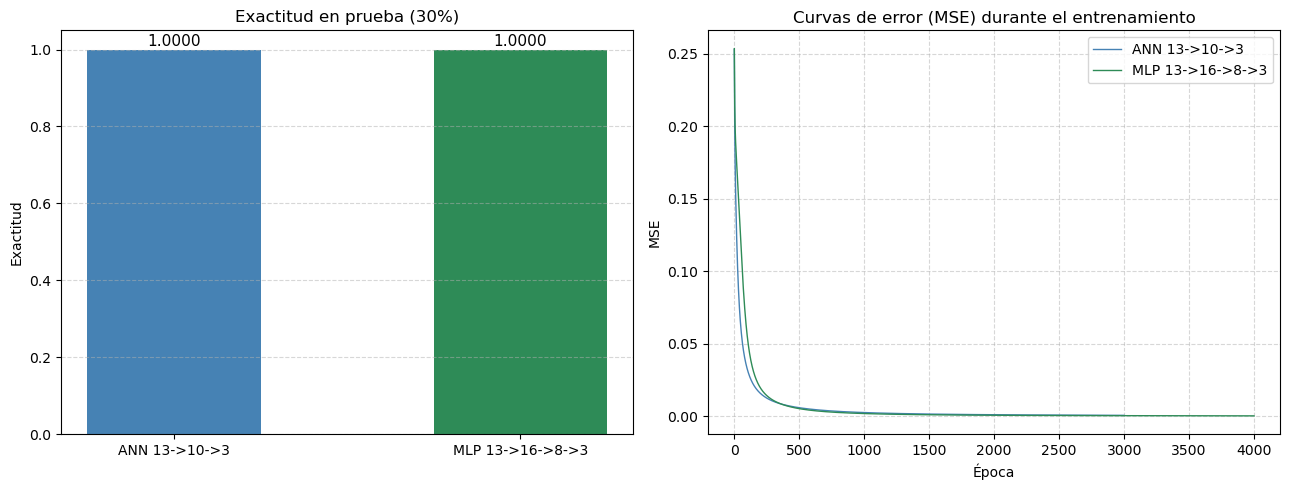

In [68]:
# Comparación de resultados: ANN (1 capa oculta) vs MLP (2 capas ocultas)
exactitud_ann = np.mean(pred_te == y_te)

print("=== Comparación ANN vs MLP (conjunto de prueba 30%) ===")
print(f"ANN  13->10->3   : exactitud = {exactitud_ann:.4f} | MSE train = {historial_wine[-1]:.4f}")
print(f"MLP  13->16->8->3: exactitud = {exactitud_mlp:.4f} | MSE train = {historial_mlp[-1]:.4f}")
mejor = "MLP" if exactitud_mlp >= exactitud_ann else "ANN"
print(f"Mejor modelo en prueba: {mejor} (diferencia = {abs(exactitud_mlp - exactitud_ann):.4f})")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

barras = [exactitud_ann, exactitud_mlp]
axes[0].bar(["ANN 13->10->3", "MLP 13->16->8->3"], barras, color=["steelblue", "seagreen"], width=0.5)
axes[0].set_ylim(0.0, 1.05)
for i, v in enumerate(barras):
    axes[0].text(i, v + 0.01, f"{v:.4f}", ha="center", fontsize=11)
axes[0].set_title("Exactitud en prueba (30%)")
axes[0].set_ylabel("Exactitud")
axes[0].grid(True, axis="y", linestyle="--", alpha=0.5)

axes[1].plot(historial_wine, color="steelblue", linewidth=1, label="ANN 13->10->3")
axes[1].plot(historial_mlp, color="seagreen", linewidth=1, label="MLP 13->16->8->3")
axes[1].set_title("Curvas de error (MSE) durante el entrenamiento")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("MSE")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()